# BACKGROUND
A large retail company that sells daily necessities such as food, beverages, and various fruits. The company operates using a multi-channel sales strategy, physical stores, catalog sales, and e-commerce, while consistently running promotions and loyalty campaigns to attract customers.


# PROBLEM STATEMENT
The retail supermarket aims to analyze consumer behavior to understand product preferences, promotional campaign effectiveness, and potential customer churn. Specifically, the company needs to identify which products are most and least preferred, as well as which promotions or campaigns are most effective in attracting and retaining customers.

In addition, analyzing the **Churn Flag** is essential for identifying customers with a high churn risk, enabling the company to target them with the right promotions or loyalty programs to improve overall customer retention.


# STAKEHOLDERS
The results of this analysis will be used by the **Marketing Department** and the **Business/Management Department**.
The Marketing team will use the findings to evaluate the effectiveness of promotional campaigns, develop more targeted communication strategies, and optimize customer loyalty programs.

Meanwhile, the Business/Management team will leverage these insights to support strategic decision-making related to product development and customer segmentation.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

import warnings
warnings.filterwarnings("ignore")

# DATA

dataset berisi informasi terkait beberapa kategori seperti

People:

* ID: Customer's unique identifier
* Year_Birth: Customer's birth year
* Education: Customer's education level
* Marital_Status: Customer's marital status
* Income: Customer's yearly household income
* Kidhome: Number of children in customer's household
* Teenhome: Number of teenagers in customer's household
* Dt_Customer: Date of customer's enrollment with the company
* Recency: Number of days since customer's last purchase
* Complain: 1 if the customer complained in the last 2 years, 0 otherwise


Products:

* MntWines: Amount spent on wine in last 2 years
* MntFruits: Amount spent on fruits in last 2 years
* MntMeatProducts: Amount spent on meat in last 2 years
* MntFishProducts: Amount spent on fish in last 2 years
* MntSweetProducts: Amount spent on sweets in last 2 years
* MntGoldProds: Amount spent on gold in last 2 years


Promotion:
* NumDealsPurchases: Number of purchases made with a discount
* AcceptedCmp1: 1 if the customer accepted the offer in the 1st campaign, 0 otherwise
* AcceptedCmp2: 1 if the customer accepted the offer in the 2nd campaign, 0 otherwise
* AcceptedCmp3: 1 if the customer accepted the offer in the 3rd campaign, 0 otherwise
* AcceptedCmp4: 1 if the customer accepted the offer in the 4th campaign, 0 otherwise
* AcceptedCmp5: 1 if the customer accepted the offer in the 5th campaign, 0 otherwise
* Response: 1 if the customer accepted the offer in the last campaign, 0 otherwis


Place:

* NumWebPurchases: Number of purchases made through the company’s website
* NumCatalogPurchases: Number of purchases made using a catalog
* NumStorePurchases: Number of purchases made directly in stores
* NumWebVisitsMonth: Number of visits to the company’s website in the last month

Additional:
* Churn_Flag: Customer churn risk

In [59]:
df=pd.read_csv(r"C:\Users\user\OneDrive\Documents\Dwiky\Data Analyst\Purwadhika\Module 3 - Data Analysis\Capstone\Supermarket_Customers.csv")
display(df.head(),df.tail())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,5,0,0,0,0,0,0,3,11,0


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25/01/2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24/01/2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15/10/2012,40,84,...,7,0,0,0,0,0,0,3,11,1


# DATA UNDERSTANDING

First, we begin by reviewing the overall information contained in the dataset.

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Assessing data cleanliness by identifying the number of missing values and unique values in each column.

In [61]:
columns = df.columns
dtype = df.dtypes
missing_value = round(df.isnull().sum())
total_unique = [len(df[i].unique()) for i in df.columns]
unique = [df[i].unique() for i in df.columns]

desciption = pd.DataFrame({
    'type': df.dtypes ,
    'missing_value': missing_value,
    'total_unique_value': total_unique,
    'unique': unique
})

desciption

,type,missing_value,total_unique_value,unique
ID,int64,0,2240,"[5524, 2174, 4141, 6182, 5324, 7446, 965, 6177..."
Year_Birth,int64,0,59,"[1957, 1954, 1965, 1984, 1981, 1967, 1971, 198..."
Education,object,0,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
Marital_Status,object,0,8,"[Single, Together, Married, Divorced, Widow, A..."
Income,float64,24,1975,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0, ..."
Kidhome,int64,0,3,"[0, 1, 2]"
Teenhome,int64,0,3,"[0, 1, 2]"
Dt_Customer,object,0,663,"[04/09/2012, 08/03/2014, 21/08/2013, 10/02/201..."
Recency,int64,0,100,"[58, 38, 26, 94, 16, 34, 32, 19, 68, 11, 59, 8..."
MntWines,int64,0,776,"[635, 11, 426, 173, 520, 235, 76, 14, 28, 5, 6..."


Superstore_Customer Dataset
* Contains **2,240 rows and 29 columns**
* Only the `Income` column has missing values
* The `Year_Birth` column can be converted into `Age` to simplify analysis
* The `Marital_Status` column can be simplified for clearer categorization


In [62]:
df.isna().sum()/df.shape[0]*100

ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0.000000
Teenhome               0.000000
Dt_Customer            0.000000
Recency                0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
Complain               0.000000
Z_CostContact          0.000000
Z_Revenue              0.000000
Response               0.000000
dtype: float64

Missing values account for only **1% of the entire dataset** (found in the `Income` column).
To address this, I will fill the missing values by calculating the **average income grouped by Education level**, ensuring a more accurate and context-appropriate replacement.

Looking for duplicate data

In [63]:
df.duplicated().sum()

np.int64(0)

No duplicate entries were found in the entire dataset.

# DATA CLEANING

#### Adding new column `Churn_Flag`

In [64]:
df['Churn_Flag'] = df['Recency'].apply(lambda x: 
0 if x <= 30 else 
1 if x <= 60 else 
2)

df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Churn_Flag
0,5524,1957,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,0,0,0,0,0,0,3,11,1,1
1,2174,1954,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,0,0,0,0,0,0,3,11,0,1
2,4141,1965,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,0,0,0,0,0,0,3,11,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,0,0,0,0,0,0,3,11,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,0,0,0,0,0,0,3,11,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,0,0,0,0,0,0,3,11,0,1
2236,4001,1946,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,0,0,0,1,0,0,3,11,0,1
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25/01/2014,91,908,...,0,1,0,0,0,0,3,11,0,2
2238,8235,1956,Master,Together,69245.0,0,1,24/01/2014,8,428,...,0,0,0,0,0,0,3,11,0,0


An additional column named **Churn_Flag** was created to identify the level of churn risk for each customer. The classification is defined as follows:

* **0** → Recency ≤ 30 days (**Active**)
* **1** → Recency 31–60 days (**At Risk**)
* **2** → Recency > 60 days (**Churn**)

This three-level segmentation was chosen because the dataset’s *Recency* values range from 0 to 99 days, allowing the range to be evenly divided into three meaningful churn risk categories.

#### Creating a new variable called **Total Spending** for use in subsequent calculations and analysis.

In [65]:
product_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

total_spending_per_category = df[product_cols].sum().sort_values(ascending=False)
print(total_spending_per_category)

df_total_spending = total_spending_per_category.reset_index()
df_total_spending.columns = ['Product_Category', 'Total_Spending']
print(df_total_spending)


MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64
   Product_Category  Total_Spending
0          MntWines          680816
1   MntMeatProducts          373968
2      MntGoldProds           98609
3   MntFishProducts           84057
4  MntSweetProducts           60621
5         MntFruits           58917


In [66]:
df = df.assign(
    Total_Spending = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1),
    Total_Product_Category = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].gt(0).sum(axis=1),
    Total_Campaign_Accepted = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)
)


#### Change 'Year_Birth' column, to 'Age'

In [67]:
current_year = datetime.now().year #menentukan tahun sekarang
df['Year_Birth'] = current_year - df['Year_Birth']
df.rename(columns={'Year_Birth': 'Age'}, inplace=True)
df

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Churn_Flag,Total_Spending,Total_Product_Category,Total_Campaign_Accepted
0,5524,69,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,0,0,0,3,11,1,1,1617,6,1
1,2174,72,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,0,0,0,3,11,0,1,27,6,0
2,4141,61,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,0,0,0,3,11,0,0,776,6,0
3,6182,42,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,0,0,0,3,11,0,0,53,6,0
4,5324,45,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,0,0,0,3,11,0,2,422,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,59,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,0,0,0,3,11,0,1,1341,6,0
2236,4001,80,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,1,0,0,3,11,0,1,444,3,1
2237,7270,45,Graduation,Divorced,56981.0,0,0,25/01/2014,91,908,...,0,0,0,3,11,0,2,1241,6,1
2238,8235,70,Master,Together,69245.0,0,1,24/01/2014,8,428,...,0,0,0,3,11,0,0,843,6,0


In [68]:
df['Age'].unique()

array([ 69,  72,  61,  42,  45,  59,  55,  41,  52,  76,  43,  50,  67,
        74,  39,  80,  46,  77,  44,  47,  75,  57,  40,  37,  63,  56,
        53,  83,  51,  30,  58,  62,  49,  48,  71,  60,  38,  78,  68,
        54,  66,  81,  35,  64,  73,  65,  70,  34, 126, 133,  36,  79,
       127,  33,  32,  85,  82,  31,  86])

In [69]:
df[df['Age']>100]

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Churn_Flag,Total_Spending,Total_Product_Category,Total_Campaign_Accepted
192,7829,126,2n Cycle,Divorced,36640.0,1,0,26/09/2013,99,15,...,0,0,1,3,11,0,2,65,6,0
239,11004,133,2n Cycle,Single,60182.0,0,1,17/05/2014,23,8,...,0,0,0,3,11,0,0,22,4,0
339,1150,127,PhD,Together,83532.0,0,0,26/09/2013,36,755,...,0,0,0,3,11,0,1,1853,6,1


In the `Age` column, several values were identified as abnormal, specifically ages over 100 years. These entries will be corrected by replacing them with the **average age grouped by the Education level**, ensuring more realistic and consistent age data across the dataset.


In [70]:
df.groupby('Education')['Age'].mean().round()

Education
2n Cycle      54.0
Basic         49.0
Graduation    56.0
Master        59.0
PhD           60.0
Name: Age, dtype: float64

In [71]:
df.loc[df['Age'] > 100, 'Age'] = (
    df.groupby('Education')['Age'].transform('median')
)

I have successfully calculated the average age for each Education level, and all anomalous age values above 100 have been replaced with the corresponding Education-based average.

#### Next, I will simplify the `Marital_Status` categories and clean several inconsistent entries.

In [72]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [73]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Widow': 'Single',
    'Divorced': 'Single',
    'Alone': 'Single',
    'Absurd': 'Unknown',
    'YOLO': 'Unknown'
})
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Unknown'], dtype=object)

I combined *widow*, *divorced*, and *alone* into one category, namely **“Single.”** I also grouped *Absurd* and *YOLO* into **“Unknown”** because they have no correlation with marital status.

#### In the next stage, I will clean the Income data, which contains 24 missing values. These missing values will be filled using the median calculated based on Education.

In [74]:
# Calculate Q1 (25%), Q3 (75%), and the IQR.
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

# Determine the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Filter the outlier data.
outliers = df[(df['Income'] < lower_bound) | (df['Income'] > upper_bound)]
print("Jumlah outlier:", len(outliers))

# Display the outliers.
outliers

Lower bound: -14525.5
Upper bound: 118350.5
Jumlah outlier: 8


,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Churn_Flag,Total_Spending,Total_Product_Category,Total_Campaign_Accepted
164,8475,53,PhD,Married,157243.0,0,1,01/03/2014,98,20,...,0,0,0,3,11,0,2,1608,6,0
617,1503,50,PhD,Together,162397.0,1,1,03/06/2013,31,85,...,0,0,0,3,11,0,1,107,6,0
655,5555,51,Graduation,Single,153924.0,0,0,07/02/2014,81,1,...,0,0,0,3,11,0,2,6,6,0
687,1501,44,PhD,Married,160803.0,0,0,04/08/2012,21,55,...,0,0,0,3,11,0,0,1717,6,0
1300,5336,55,Master,Together,157733.0,1,0,04/06/2013,37,39,...,0,0,0,3,11,0,1,59,5,0
1653,4931,49,Graduation,Together,157146.0,0,0,29/04/2013,13,1,...,0,0,0,3,11,0,0,1730,5,0
2132,11181,77,PhD,Married,156924.0,0,0,29/08/2013,85,2,...,0,0,0,3,11,0,2,8,6,0
2233,9432,49,Graduation,Together,666666.0,1,0,02/06/2013,23,9,...,0,0,0,3,11,0,0,62,6,0


After conducting a thorough review, one abnormal data point was found: an income value of **“666666.”** I will treat this value the same way as missing data by replacing it with the median.

In [75]:
df.groupby(['Education'])['Income'].median().round(0)

Education
2n Cycle      46805.0
Basic         20744.0
Graduation    52028.0
Master        50943.0
PhD           55212.0
Name: Income, dtype: float64

In [76]:
df['Income'] = df.groupby(['Education'])['Income'].transform(lambda x: x.fillna(x.median()))
df.loc[df['Income'] == 666666, 'Income'] = (
    df.groupby('Education')['Income'].transform('median')
)

In [77]:
df['Education'].isna().sum()

np.int64(0)

In [78]:
df[df['ID'] == 9432]

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Churn_Flag,Total_Spending,Total_Product_Category,Total_Campaign_Accepted
2233,9432,49,Graduation,Together,52028.5,1,0,02/06/2013,23,9,...,0,0,0,3,11,0,0,62,6,0


The **Income** data no longer contains any missing or abnormal values.

#### In the next stage, I will remove the `Z_CostContact` and `Z_Revenue` columns.

`Z_CostContact` represents the cost incurred each time the company contacts a customer, such as during direct promotions via SMS or email. Meanwhile, `Z_Revenue` refers to the average revenue per customer from previous campaigns.

I will drop these two columns because they do not contribute to the problem statement I will analyze, and their values are identical across all records.

In [79]:
df.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)
df

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Churn_Flag,Total_Spending,Total_Product_Category,Total_Campaign_Accepted
0,5524,69,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,0,0,0,0,0,1,1,1617,6,1
1,2174,72,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,0,0,0,0,0,0,1,27,6,0
2,4141,61,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,0,0,0,0,0,0,0,776,6,0
3,6182,42,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,0,0,0,0,0,0,0,53,6,0
4,5324,45,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,0,0,0,0,0,0,2,422,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,59,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,0,0,0,0,0,0,1,1341,6,0
2236,4001,80,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,0,0,1,0,0,0,1,444,3,1
2237,7270,45,Graduation,Single,56981.0,0,0,25/01/2014,91,908,...,1,0,0,0,0,0,2,1241,6,1
2238,8235,70,Master,Together,69245.0,0,1,24/01/2014,8,428,...,0,0,0,0,0,0,0,843,6,0


In [80]:
df.isna().sum()

ID                         0
Age                        0
Education                  0
Marital_Status             0
Income                     0
Kidhome                    0
Teenhome                   0
Dt_Customer                0
Recency                    0
MntWines                   0
MntFruits                  0
MntMeatProducts            0
MntFishProducts            0
MntSweetProducts           0
MntGoldProds               0
NumDealsPurchases          0
NumWebPurchases            0
NumCatalogPurchases        0
NumStorePurchases          0
NumWebVisitsMonth          0
AcceptedCmp3               0
AcceptedCmp4               0
AcceptedCmp5               0
AcceptedCmp1               0
AcceptedCmp2               0
Complain                   0
Response                   0
Churn_Flag                 0
Total_Spending             0
Total_Product_Category     0
Total_Campaign_Accepted    0
dtype: int64

I only cleaned three columns: **Age**, **Marital_Status**, and **Income**, and I dropped the **Z_CostContact** and **Z_Revenue** columns. The remaining columns were not cleaned further because no anomalies or missing values were found. Additionally, I already have sufficient data to proceed with the analysis.

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2240 non-null   int64  
 1   Age                      2240 non-null   int64  
 2   Education                2240 non-null   object 
 3   Marital_Status           2240 non-null   object 
 4   Income                   2240 non-null   float64
 5   Kidhome                  2240 non-null   int64  
 6   Teenhome                 2240 non-null   int64  
 7   Dt_Customer              2240 non-null   object 
 8   Recency                  2240 non-null   int64  
 9   MntWines                 2240 non-null   int64  
 10  MntFruits                2240 non-null   int64  
 11  MntMeatProducts          2240 non-null   int64  
 12  MntFishProducts          2240 non-null   int64  
 13  MntSweetProducts         2240 non-null   int64  
 14  MntGoldProds            

In [82]:
df

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Churn_Flag,Total_Spending,Total_Product_Category,Total_Campaign_Accepted
0,5524,69,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,0,0,0,0,0,1,1,1617,6,1
1,2174,72,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,0,0,0,0,0,0,1,27,6,0
2,4141,61,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,0,0,0,0,0,0,0,776,6,0
3,6182,42,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,0,0,0,0,0,0,0,53,6,0
4,5324,45,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,0,0,0,0,0,0,2,422,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,59,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,0,0,0,0,0,0,1,1341,6,0
2236,4001,80,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,0,0,1,0,0,0,1,444,3,1
2237,7270,45,Graduation,Single,56981.0,0,0,25/01/2014,91,908,...,1,0,0,0,0,0,2,1241,6,1
2238,8235,70,Master,Together,69245.0,0,1,24/01/2014,8,428,...,0,0,0,0,0,0,0,843,6,0


# EXPLORATORY DATA ANALYSIS

#### Age distribution

Text(0.5, 1.0, 'Distribusi Umur Pelanggan')

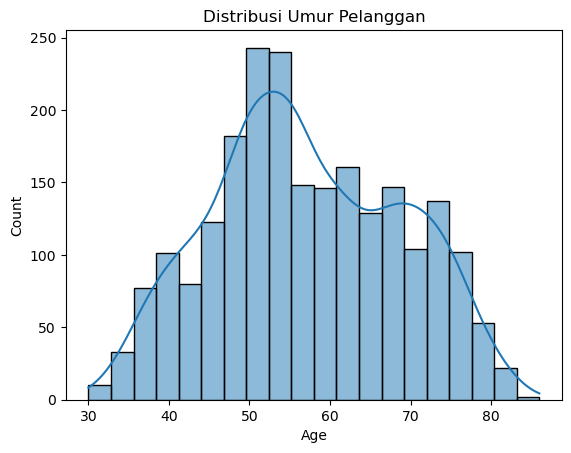

In [83]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribusi Umur Pelanggan')


The customer age distribution is normal, with a dominant age of around 50 years.=

#### Recency distribution

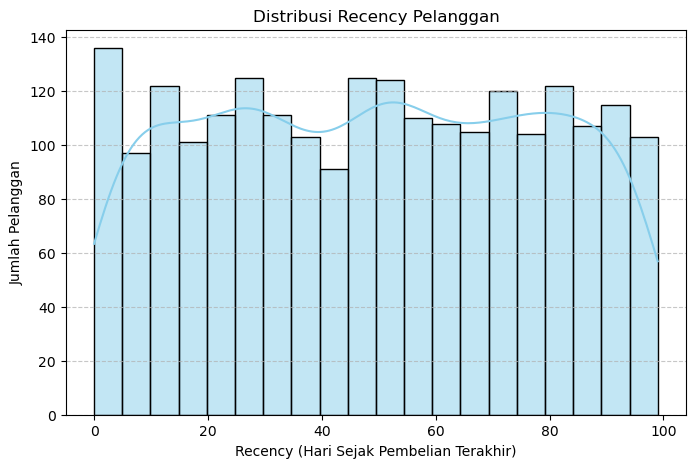

In [84]:
plt.figure(figsize=(8,5))
sns.histplot(df['Recency'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribusi Recency Pelanggan')
plt.xlabel('Recency (Hari Sejak Pembelian Terakhir)')
plt.ylabel('Jumlah Pelanggan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The recency distribution shows that recency levels are relatively evenly spread.

#### Data Complain

In [85]:
complain_df = df[df['Complain'] == 1]
complain_df


,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Churn_Flag,Total_Spending,Total_Product_Category,Total_Campaign_Accepted
78,10401,50,2n Cycle,Together,26326.0,0,0,04/09/2013,12,1,...,0,0,0,0,1,0,0,18,4,0
147,3120,45,Graduation,Together,38547.0,1,0,28/08/2013,49,6,...,0,0,0,0,1,0,1,22,5,0
192,7829,51,2n Cycle,Single,36640.0,1,0,26/09/2013,99,15,...,0,0,0,0,1,0,2,65,6,0
271,5726,43,Master,Single,31788.0,1,0,20/03/2014,15,16,...,0,0,0,0,1,0,0,60,5,0
355,6201,48,Graduation,Single,38643.0,1,1,29/11/2013,45,22,...,0,0,0,0,1,0,1,49,5,0
358,6142,83,Master,Married,65073.0,0,0,20/08/2013,65,629,...,0,0,0,0,1,0,2,900,5,0
590,3710,42,PhD,Single,39684.0,1,0,12/10/2012,41,19,...,0,0,0,0,1,1,1,81,5,1
972,10995,38,2n Cycle,Married,15716.0,1,0,12/11/2012,8,16,...,0,0,0,0,1,0,0,92,6,0
1041,6730,72,Graduation,Married,38998.0,1,1,03/11/2012,92,34,...,0,0,0,0,1,0,2,54,4,0
1069,2875,48,Graduation,Married,67023.0,0,0,04/03/2014,93,444,...,0,0,0,0,1,0,2,906,6,0


In [86]:
complain_by_churn = complain_df['Churn_Flag'].value_counts().sort_index().reset_index()
complain_by_churn.columns = ['Churn_Flag', 'Count']
print(complain_by_churn)


   Churn_Flag  Count
0           0      5
1           1      8
2           2      8


From the data above, it can be seen that customers who submitted complaints have a higher **churn risk**.

#### Churn Risk by Marital Status

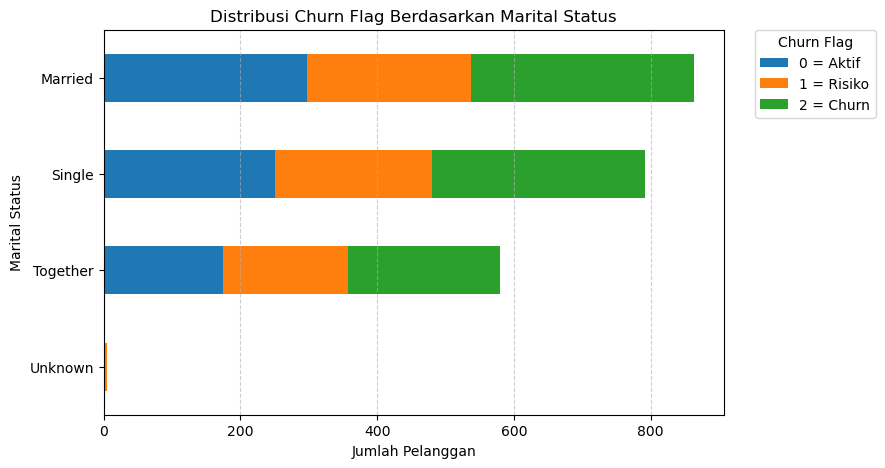

In [87]:
marital_churn = pd.crosstab(df['Marital_Status'], df['Churn_Flag'])

marital_churn.plot(kind='barh', stacked=True, figsize=(8,5))

plt.title('Distribusi Churn Flag Berdasarkan Marital Status')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Marital Status')
plt.legend(title='Churn Flag', labels=['0 = Aktif', '1 = Risiko', '2 = Churn'])
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()

plt.legend(
    title='Churn Flag',
    labels=['0 = Aktif', '1 = Risiko', '2 = Churn'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
plt.show()

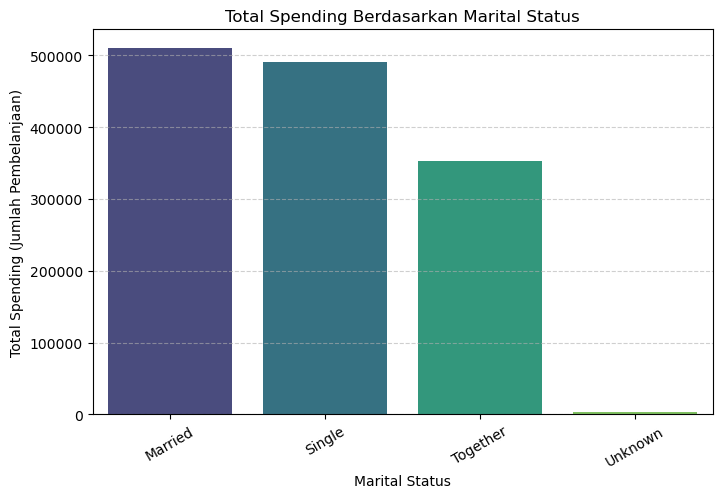

In [88]:
spending_by_marital = df.groupby('Marital_Status')['Total_Spending'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Marital_Status', y='Total_Spending', data=spending_by_marital, palette='viridis')

plt.title('Total Spending Berdasarkan Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Spending (Jumlah Pembelanjaan)')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In the marital status category, the highest total spending comes from customers who are **Married**.

Additionally, the churn risk is fairly evenly distributed across all marital status categories. Therefore, it can be concluded that churn risk does not depend on the customer’s marital status.

In [89]:
# Calculate the total spending per category.
category_spending = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum()

# Sort from the largest to the smallest.
category_spending = category_spending.sort_values(ascending=False)
category_spending


MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64

#### To see which product category has been the most popular over the last two years, it can be concluded that **wine** is the most preferred product, while **fruits** are the least preferred.

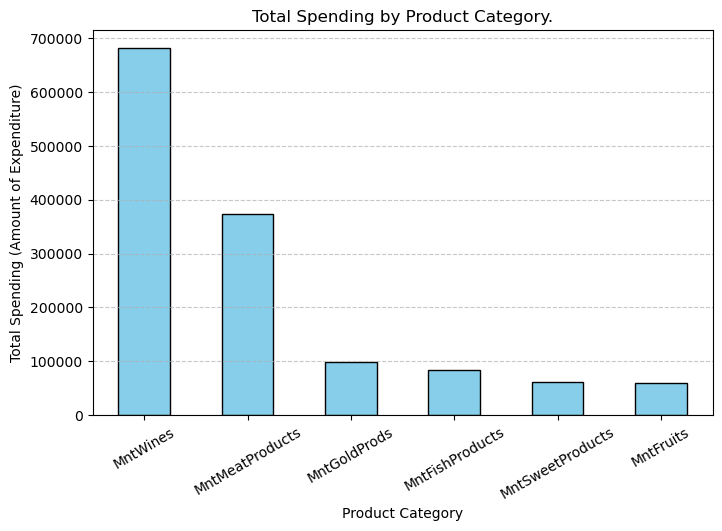

In [90]:
plt.figure(figsize=(8,5))
category_spending.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Total Spending by Product Category.')
plt.xlabel('Product Category')
plt.ylabel('Total Spending (Amount of Expenditure)')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Looking the distribution of platform usage.

In [91]:
# Calculate the total transactions per platform.
platform_spending = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].sum()

# Convert it into a DataFrame.
platform_spending = platform_spending.sort_values(ascending=False)
print(platform_spending)

NumStorePurchases      12970
NumWebVisitsMonth      11909
NumWebPurchases         9150
NumCatalogPurchases     5963
dtype: int64


* Customers still prefer making purchases by visiting physical stores directly.
* Although many customers visited the website (a total of 11,909 visits), only 9,150 purchases were made through the website platform.

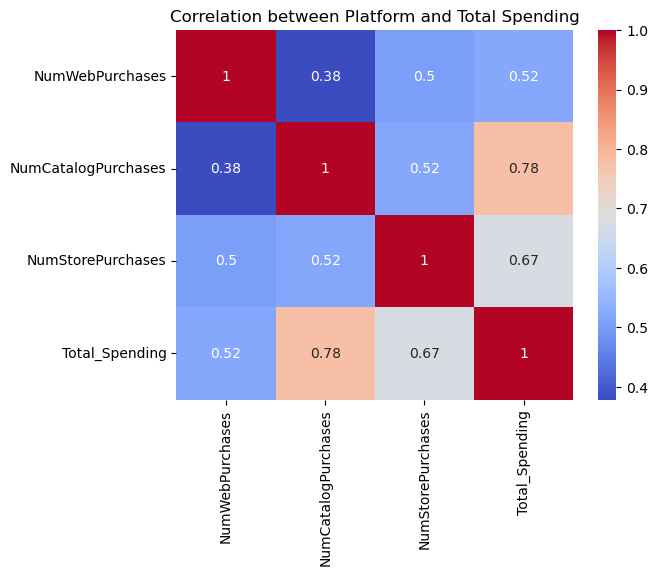

In [92]:
corr_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','Total_Spending']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Platform and Total Spending')
plt.show()

Although in-store purchases are the number one choice for customers, **catalog purchases** are the platform that has the greatest influence on customers’ total spending.

#### Observing the recency pattern.

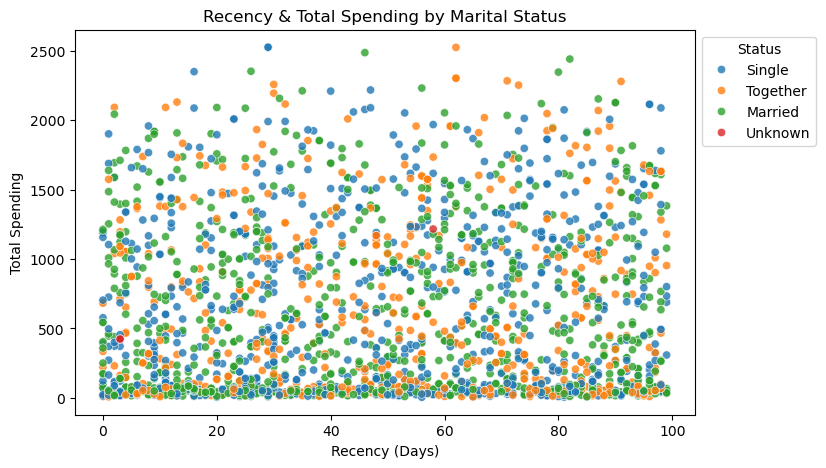

In [93]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Recency', y='Total_Spending', hue='Marital_Status', data=df, alpha=0.8)
plt.title('Recency & Total Spending by Marital Status')
plt.xlabel('Recency (Days)')
plt.ylabel('Total Spending')
plt.legend(title='Status', bbox_to_anchor=(1,1))
plt.show()

No clear pattern was found in recency. Therefore, recency is not driven by product type or customer status, but rather by shortcomings in the customer experience.

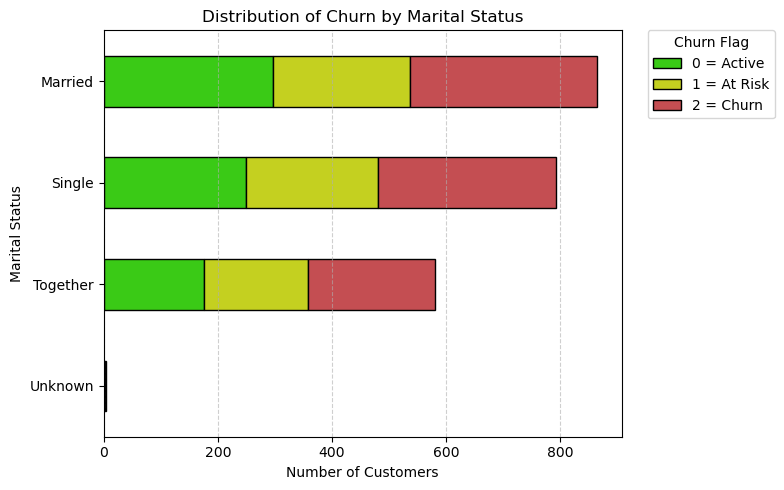

In [94]:
# Crosstab between **Marital_Status** and **Churn_Flag**.
marital_churn = pd.crosstab(df['Marital_Status'], df['Churn_Flag'])

# Sort based on the total number of customers.
marital_churn = marital_churn.loc[marital_churn.sum(axis=1).sort_values(ascending=False).index]

# Plot stacked horizontal bar chart
ax = marital_churn.plot(
    kind='barh',
    stacked=True,
    figsize=(8,5),
    color=["#3ACA16", "#C4D020", "#C44E52"],
    edgecolor='black'
)

plt.title('Distribution of Churn by Marital Status')
plt.xlabel('Number of Customers')
plt.ylabel('Marital Status')
plt.legend(
    title='Churn Flag',
    labels=['0 = Active', '1 = At Risk', '2 = Churn'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


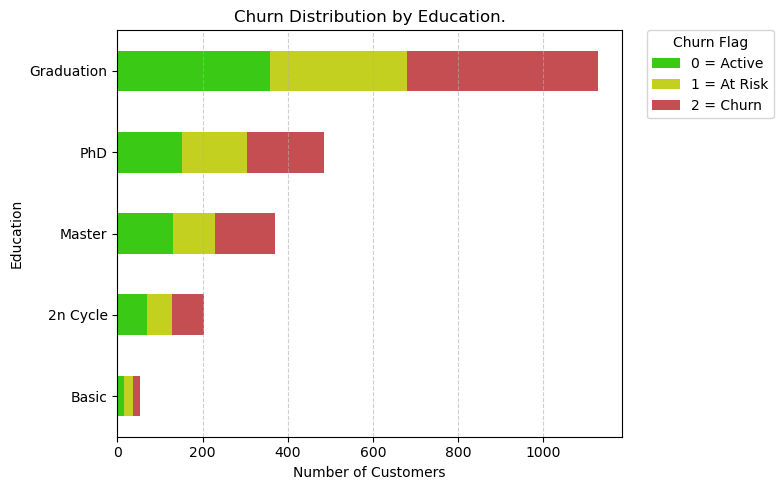

In [95]:
# Crosstab between **Education** and **Churn_Flag**.
edu_churn = pd.crosstab(df['Education'], df['Churn_Flag'])

# Sort by the total number of customers per category (descending).
edu_churn = edu_churn.loc[edu_churn.sum(axis=1).sort_values(ascending=False).index]

# Plot horizontal stacked bar chart
chart = edu_churn.plot(
    kind='barh',
    stacked=True,
    figsize=(8,5),
    color=["#3ACA16", "#C4D020", "#C44E52"]
)

plt.title('Churn Distribution by Education.')
plt.xlabel('Number of Customers')
plt.ylabel('Education')
plt.legend(
    title='Churn Flag',
    labels=['0 = Active', '1 = At Risk', '2 = Churn'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Reverse the Y-axis so that the category with the highest number of customers appears at the top.
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

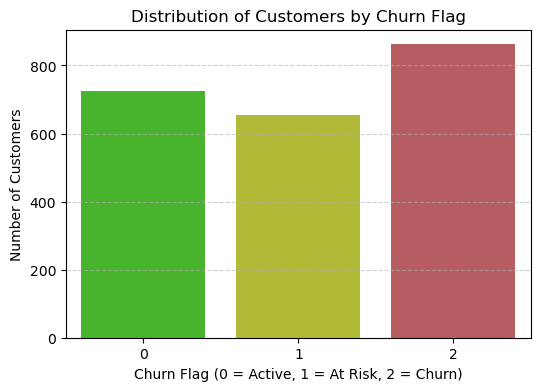

In [96]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='Churn_Flag',
    data=df,
    palette=['#3ACA16', '#C4D020', '#C44E52'] 
)

plt.title('Distribution of Customers by Churn Flag')
plt.xlabel('Churn Flag (0 = Active, 1 = At Risk, 2 = Churn)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

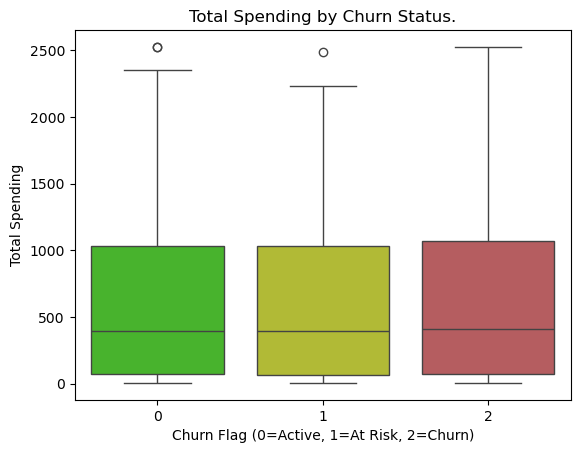

In [97]:
sns.boxplot(x='Churn_Flag', y='Total_Spending', data=df, palette=['#3ACA16', '#C4D020', '#C44E52'])
plt.title('Total Spending by Churn Status.')
plt.xlabel('Churn Flag (0=Active, 1=At Risk, 2=Churn)')
plt.ylabel('Total Spending')
plt.show()

In the scatterplot chart, a random pattern can be observed in the recency variable. After further analysis, it appears that customers with a **“Graduation”** education level represent the largest customer group, but they also show the highest churn rate.

Customer churn still remains dominant. This issue must be addressed by the company to prevent the number from increasing further.

However, it can also be seen that within both the **“Active”** and **“At Risk”** categories, there are still customers who are **top spenders**, and these customers should be retained by the company.

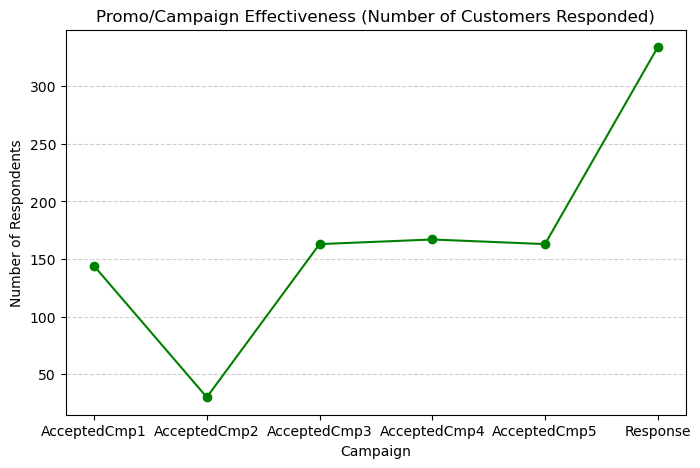

In [98]:
promo_group = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
promo_counts = df[promo_group].sum()

plt.figure(figsize=(8,5))
plt.plot(promo_counts.index, promo_counts.values, marker='o', linestyle='-', color='green')
plt.title('Promo/Campaign Effectiveness (Number of Customers Responded)')
plt.xlabel('Campaign')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


Promotional campaigns 1, 3, 4, and 5 show relatively even performance. Campaign 2 appears to be the weakest campaign, which suggests that at that time the campaign may not have offered attractive products or was communicated in a less effective way.

However, the most recent campaign, represented by **“Response,”** shows a sharp increase, indicating that the company made improvements compared to previous campaigns and successfully attracted many customers to make transactions during that period.

# Summary

* Based on the most and least purchased products, the characteristics of this supermarket’s customers suggest that they are not strongly **health-oriented**.
* The most recent campaign performed very well, showing a significant improvement compared to previous campaigns.
* The company should implement customer retention programs, such as a membership system, to maintain and engage active customers.

In [99]:
df

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Churn_Flag,Total_Spending,Total_Product_Category,Total_Campaign_Accepted
0,5524,69,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,0,0,0,0,0,1,1,1617,6,1
1,2174,72,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,0,0,0,0,0,0,1,27,6,0
2,4141,61,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,0,0,0,0,0,0,0,776,6,0
3,6182,42,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,0,0,0,0,0,0,0,53,6,0
4,5324,45,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,0,0,0,0,0,0,2,422,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,59,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,0,0,0,0,0,0,1,1341,6,0
2236,4001,80,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,0,0,1,0,0,0,1,444,3,1
2237,7270,45,Graduation,Single,56981.0,0,0,25/01/2014,91,908,...,1,0,0,0,0,0,2,1241,6,1
2238,8235,70,Master,Together,69245.0,0,1,24/01/2014,8,428,...,0,0,0,0,0,0,0,843,6,0


# Import into a CSV file.

In [100]:
df.to_csv(r"C:\Users\user\OneDrive\Documents\Dwiky\Data Analyst\Purwadhika\Module 3 - Data Analysis\Capstone\Clean_Supermarket_Customers.csv", index=False)

In [101]:
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']

campaign_sum = df[campaign_cols].sum().reset_index()
campaign_sum.columns = ['Campaign', 'Responded']

# Rename the column names to make them cleaner and more organized.
campaign_sum['Campaign'] = campaign_sum['Campaign'].replace({
    'AcceptedCmp1': 'Cmp 1',
    'AcceptedCmp2': 'Cmp 2',
    'AcceptedCmp3': 'Cmp 3',
    'AcceptedCmp4': 'Cmp 4',
    'AcceptedCmp5': 'Cmp 5',
    'Response': 'Last Cmp'
})

campaign_sum.to_csv('Campaign_Timeline.csv', index=False)

In [102]:
# List of product category columns.
product_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds'
]

# Calculate the total spending for each category.
product_sum = df[product_cols].sum().reset_index()
product_sum.columns = ['Product_Category', 'Total_Spending']

# Make the category names cleaner and more readable.
product_sum['Product_Category'] = product_sum['Product_Category'].replace({
    'MntWines': 'Wines',
    'MntFruits': 'Fruits',
    'MntMeatProducts': 'Meat',
    'MntFishProducts': 'Fish',
    'MntSweetProducts': 'Sweet',
    'MntGoldProds': 'Gold'
})


product_sum.to_csv('Product_Category_Spending.csv', index=False)

In [103]:
platform_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
platform_sum = df[platform_cols].sum().reset_index()
platform_sum.columns = ['Platform', 'Total_Activity']

platform_sum['Platform'] = platform_sum['Platform'].replace({
    'NumWebPurchases': 'Web Purchases',
    'NumCatalogPurchases': 'Catalog Purchases',
    'NumStorePurchases': 'Store Purchases'
})

platform_sum.to_csv('Sales_Platform_Summary.csv', index=False)


Import the cleaned dataset into a CSV file. I also added another CSV file for data visualization purposes.